

This section imports the libraries required for data preprocessing, visualization, classification, hyperparameter tuning, and model saving.

In [91]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC


## Part A1 : Dataset Loading & Audit
Below two sections loads the dataset and performs an initial audit by checking its shape, column names, data types, missing values, target column, and class distribution.

In [66]:
#--------------------------------------PART A (DATASET LOADING &AUDIT)-------------------------------------------------

# Load dataset
df = pd.read_csv("star_classification.csv")

# 1. Dataset shape
print("Dataset Shape:", df.shape)
print("----------------------------------------------------------------------")
# 2. Column names and data types
print("\n      Data Types")
print(df.dtypes)
print("----------------------------------------------------------------------")
# 3. Missing-value counts
print("\n      Missing Values")
print(df.isnull().sum())
print("----------------------------------------------------------------------")



Dataset Shape: (100000, 18)
----------------------------------------------------------------------

      Data Types
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class              str
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object
----------------------------------------------------------------------

      Missing Values
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64
-------------------------------------------

In [67]:
# 4. Target column
target_column = "class"
print("\nTarget Column:", target_column)
print("----------------------------------------------------------------------")
# 5. Class distribution
print("\n        Class Distribution")
print(df[target_column].value_counts())
print("----------------------------------------------------------------------")
# 6. Class distribution in percentage
print("\n         Class Distribution (%)")
print(df[target_column].value_counts(normalize=True).mul(100).round(2))



Target Column: class
----------------------------------------------------------------------

        Class Distribution
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64
----------------------------------------------------------------------

         Class Distribution (%)
class
GALAXY    59.44
STAR      21.59
QSO       18.96
Name: proportion, dtype: float64


## Part A2 : EDA Visualizations

This section visualizes the numerical features using distribution plots, examines feature correlations using a heatmap, and analyzes the relationship between features and the target classes.

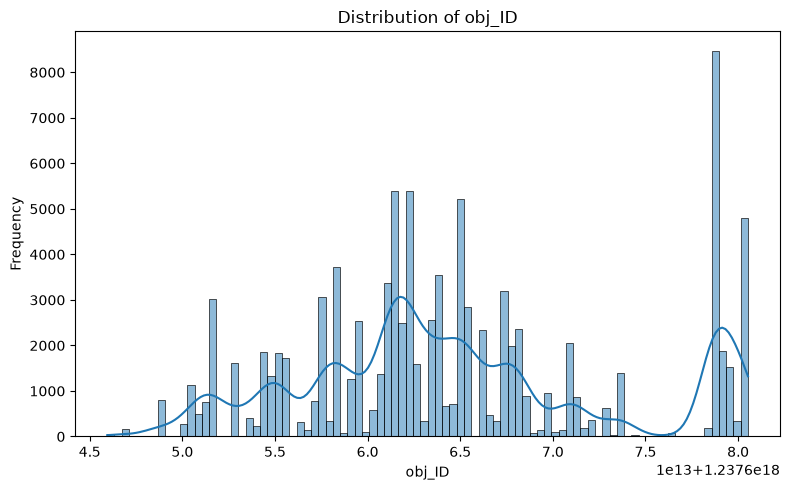

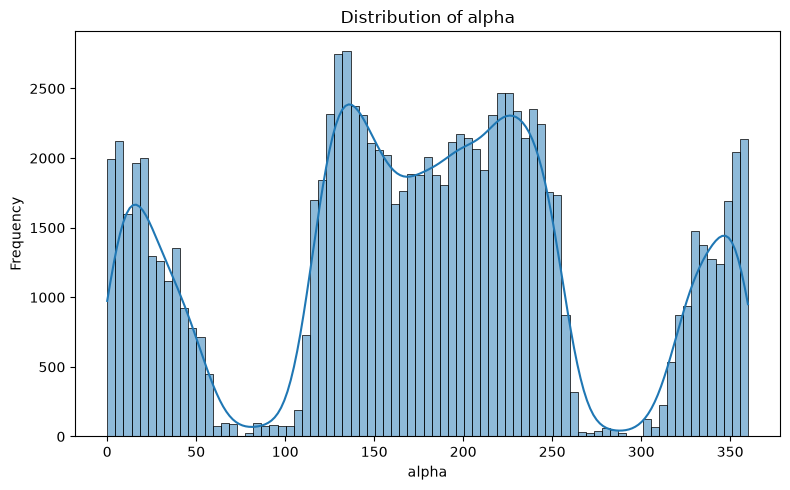

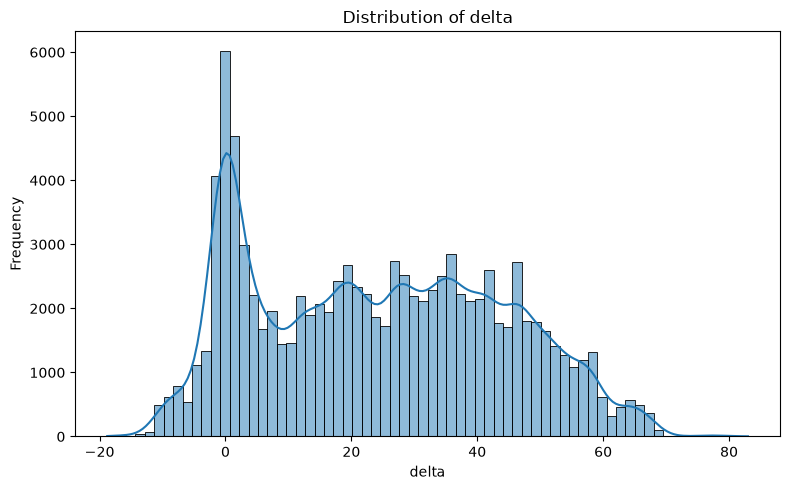

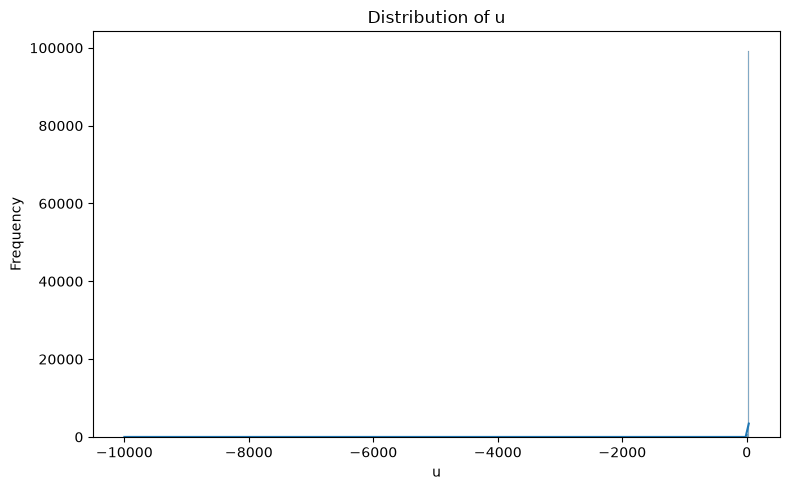

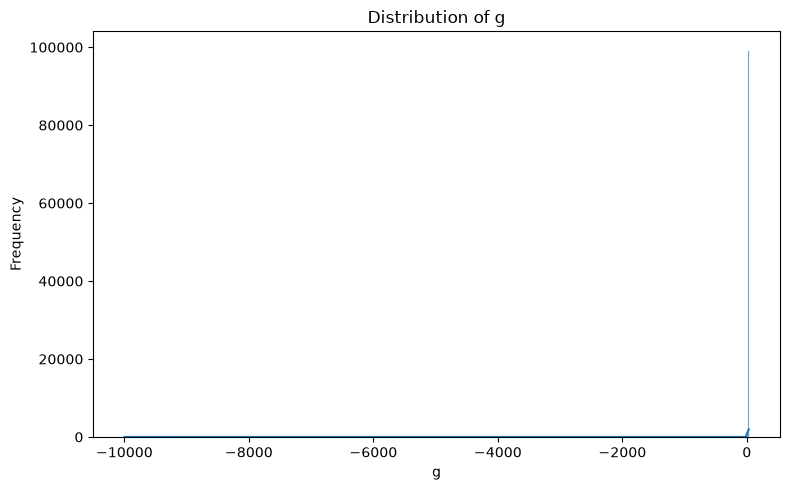

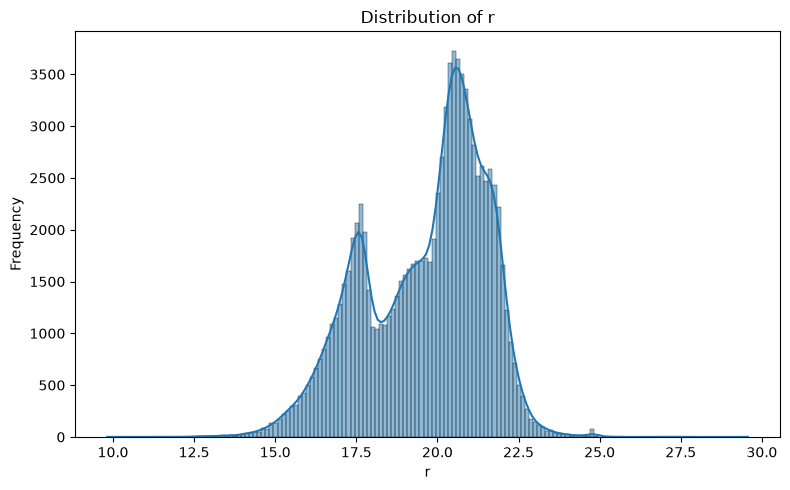

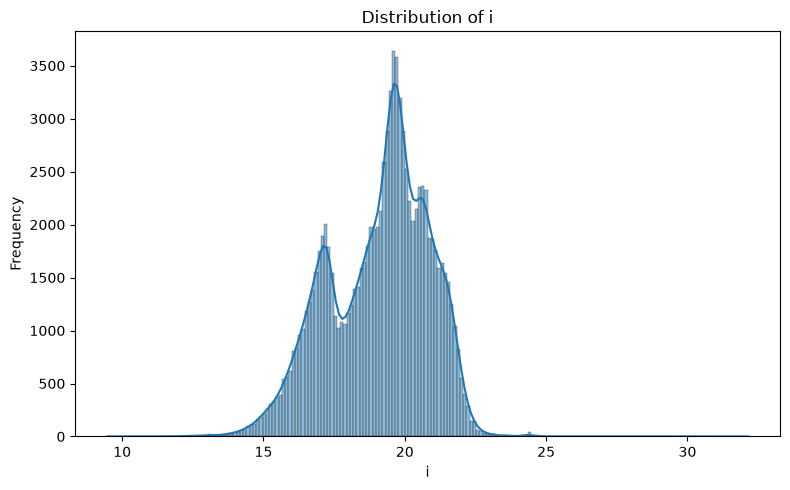

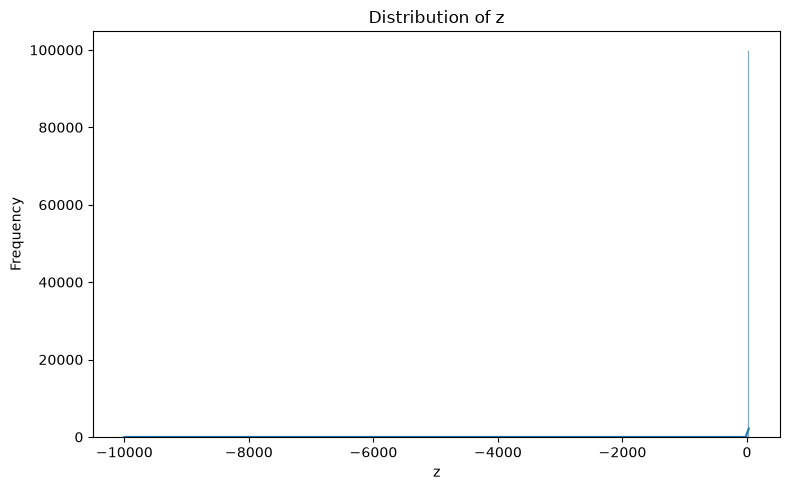

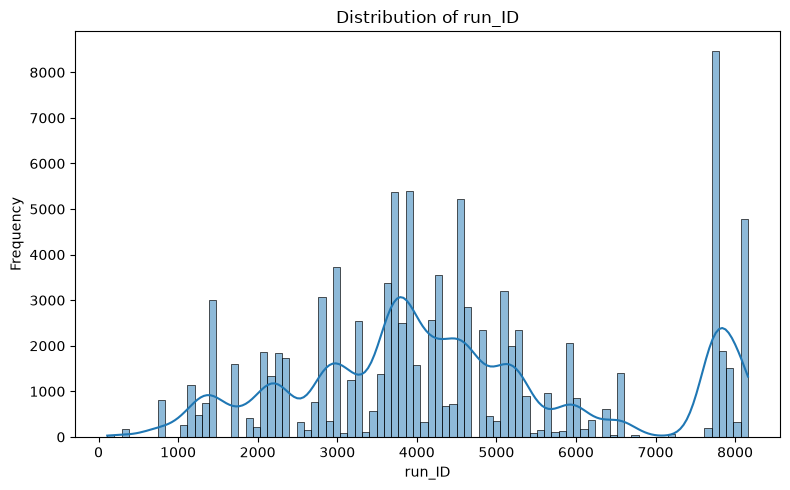

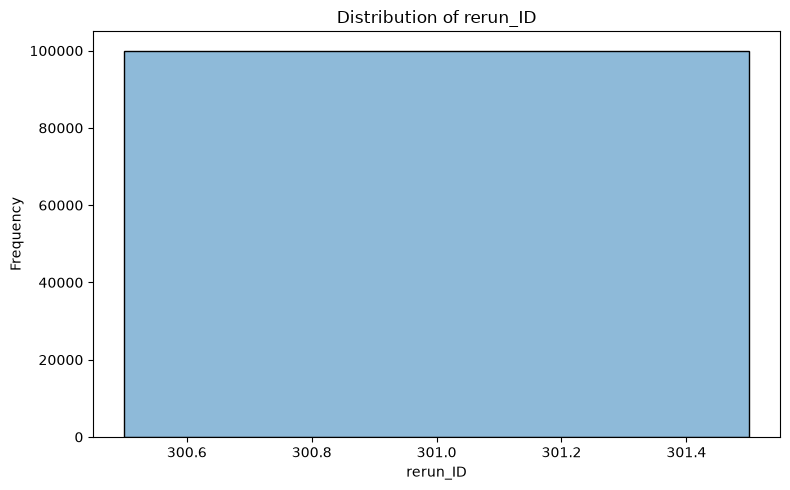

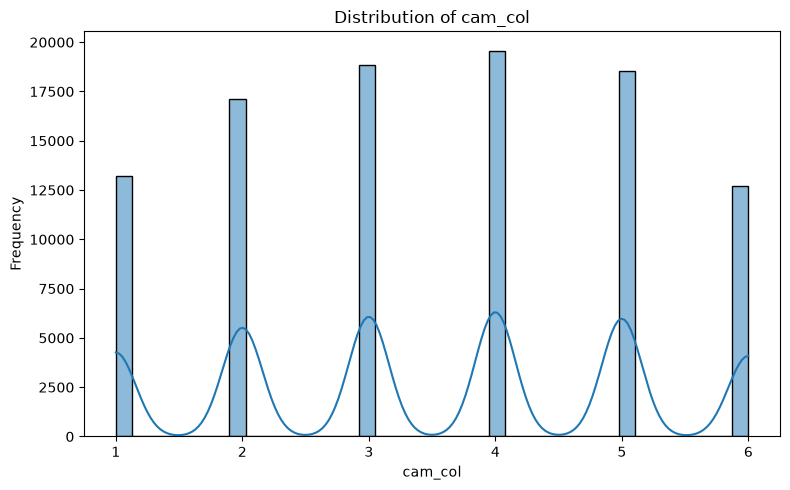

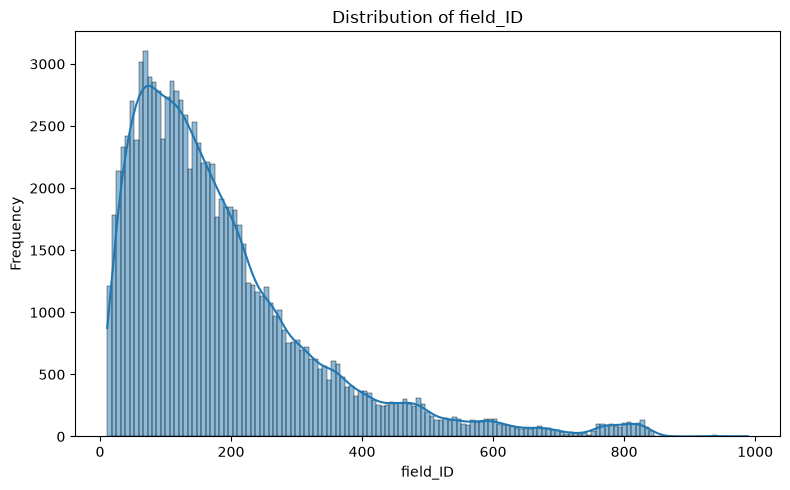

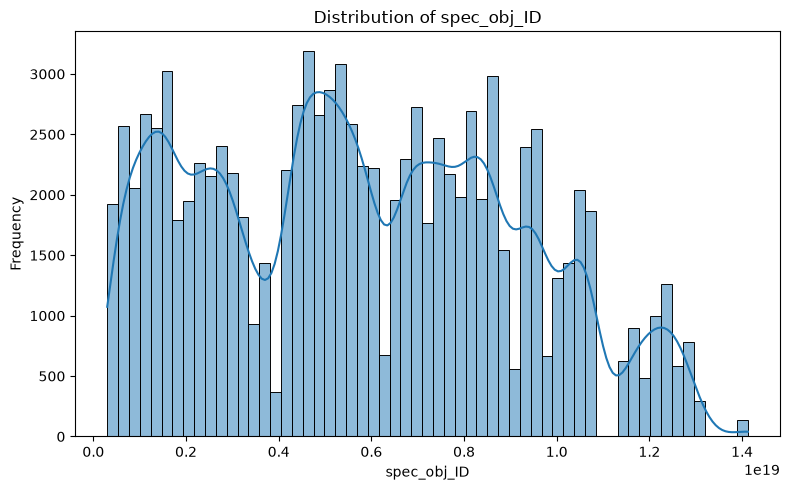

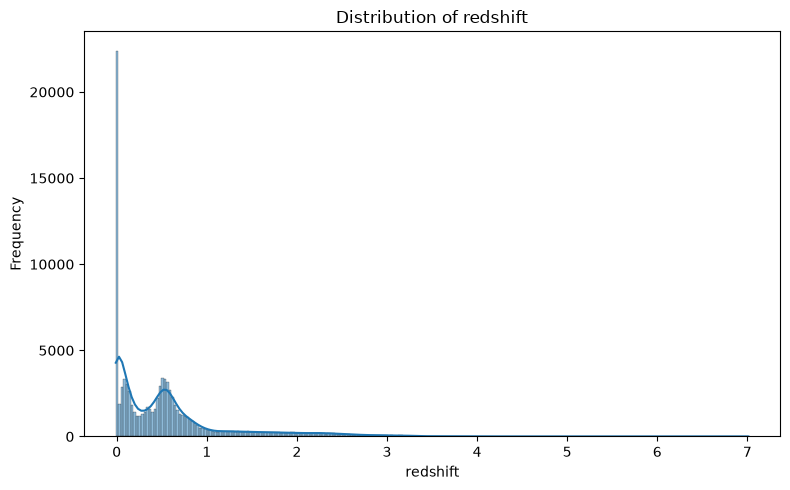

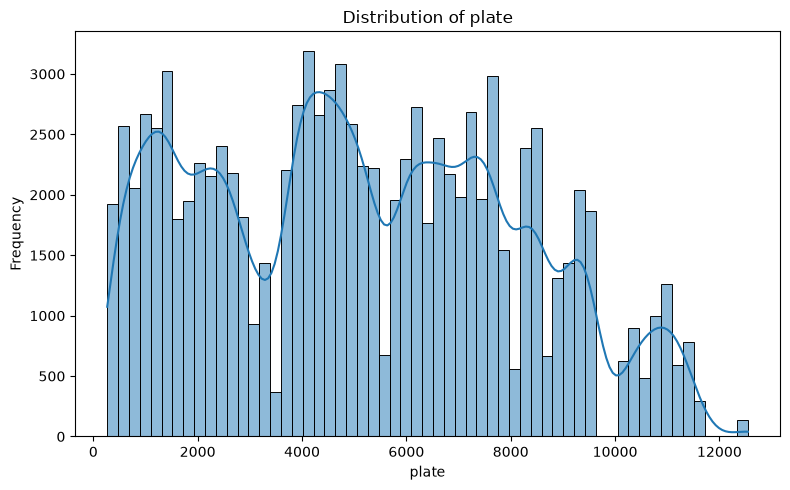

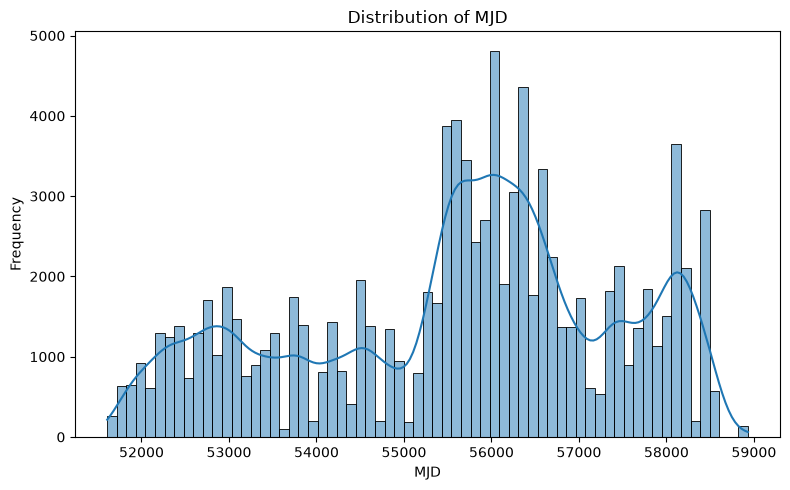

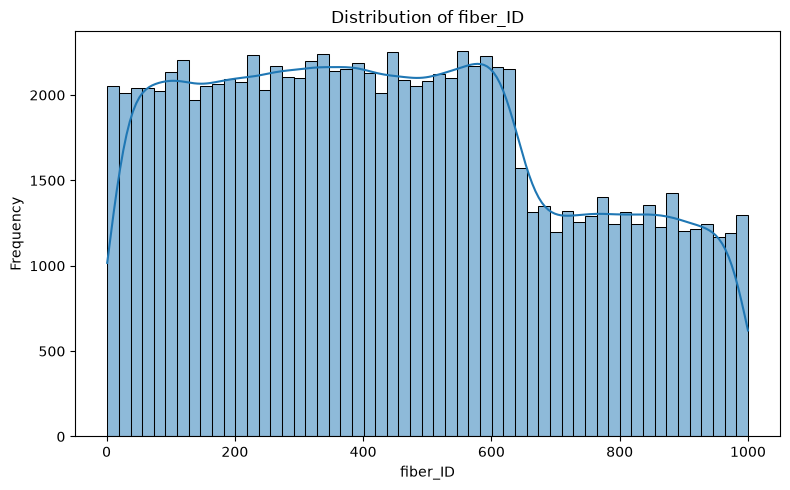

In [ ]:
#  numerical features using distribution plots 
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns

for feature in numeric_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()




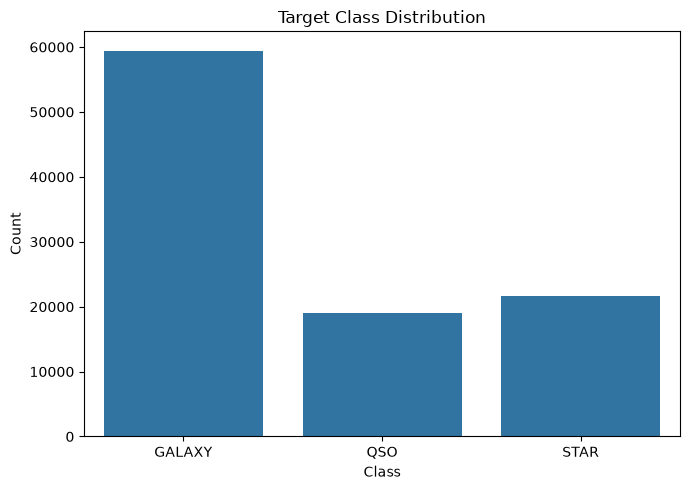

In [69]:
# -------------------------------------- A2. TARGET DISTRIBUTION --------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="class")

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

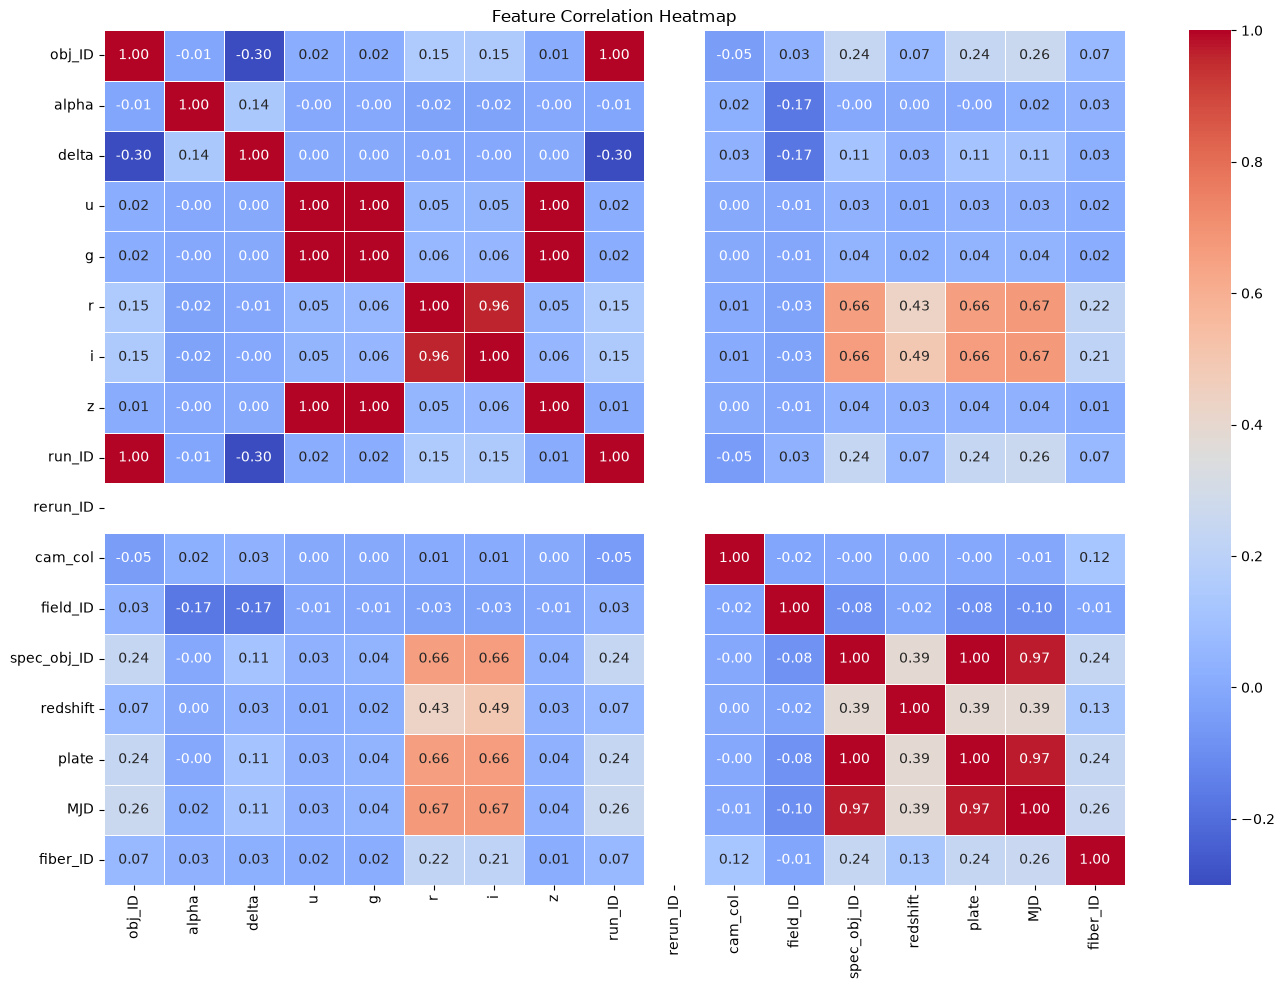

In [ ]:
# Features correlation heatmap 

plt.figure(figsize=(14, 10))

correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
#  features (vs) target classes analysation 

class_mapping = {
    "STAR": 0,
    "GALAXY": 1,
    "QSO": 2
}

df["class_numeric"] = df["class"].map(class_mapping)

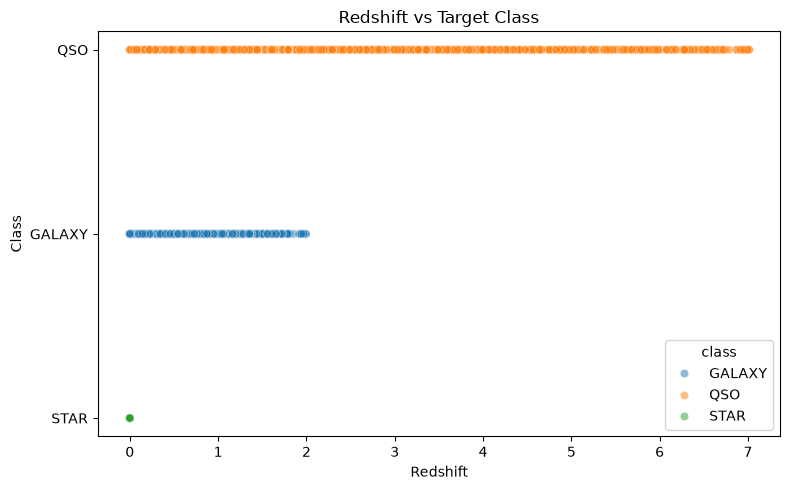

In [ ]:
#------------------------------------------- 1 . Redshift (vs) Class-----------------------------------------------------------
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="redshift",
    y="class_numeric",
    hue="class",
    alpha=0.5
)

plt.title("Redshift vs Target Class")
plt.xlabel("Redshift")
plt.ylabel("Class")
plt.yticks([0, 1, 2], ["STAR", "GALAXY", "QSO"])

plt.tight_layout()
plt.show()


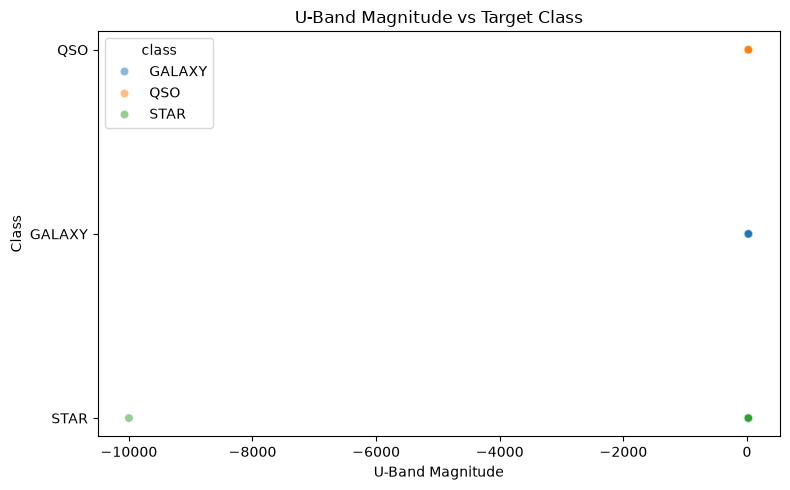

In [ ]:
#--------------------------------------------- 2. u (vs) Class---------------------------------------------------------------
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="u",
    y="class_numeric",
    hue="class",
    alpha=0.5
)

plt.title("U-Band Magnitude vs Target Class")
plt.xlabel("U-Band Magnitude")
plt.ylabel("Class")
plt.yticks([0, 1, 2], ["STAR", "GALAXY", "QSO"])

plt.tight_layout()
plt.show()

## Part B1: Data Cleaning

This section checks the dataset for missing values, duplicate records, and outliers. Missing values and duplicates are handled when present, while outliers are identified using the IQR method and treated appropriately.

In [ ]:
#removing class_numeric column created earlier for EDA visualizations 
df.drop(columns=["class_numeric"], inplace=True)

# checking if missing values existed 
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values.to_string())
total_missing = missing_values.sum()
print("\nTotal missing values:", total_missing)

if total_missing == 0:
    print("\n✓ No missing values found.")
    print("No imputation or row deletion is required.")




Missing values in each column:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0

Total missing values: 0

✓ No missing values found.
No imputation or row deletion is required.


In [ ]:

#duplicates detection & handling 
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("✓ No duplicate records found.")
else:
    print(f"Removing {duplicate_count} duplicate records...")
    df = df.drop_duplicates().reset_index(drop=True)
    print("New dataset shape:", df.shape)

Number of duplicate rows: 0
✓ No duplicate records found.


In [ ]:
# outlier detection & handling (didnot handle yet)
outlier_summary = {}
outlier_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for feature in outlier_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]
    
    outlier_summary[feature] = len(outliers)

print("Outlier count using IQR method:\n")

for feature, count in outlier_summary.items():
    print(f"{feature:10} : {count}")

Outlier count using IQR method:

obj_ID     : 0
alpha      : 0
delta      : 0
u          : 56
g          : 99
r          : 132
i          : 198
z          : 320
run_ID     : 0
rerun_ID   : 0
cam_col    : 0
field_ID   : 5391
spec_obj_ID : 0
redshift   : 8990
plate      : 0
MJD        : 0
fiber_ID   : 0


## Part B2 : Encoding, Stratified Splitting & Feature Scaling

This section separates the features and target, encodes the target classes using LabelEncoder , performs a stratified train-test split with a fixed random state (42), and applies StandardScaler by fitting only on the training data. The class distributions are also verified across the full, training, and testing datasets.

In [ ]:
# Target column
target_column = "class"

# Separate features (X) and target (y)
X = df.drop(columns=[target_column])
y = df[target_column]

# Verification 
print("Feature shape:", X.shape)
print("Target shape :", y.shape)
print("\n      Target Classes")
print(y.value_counts())

# Stratified train-test split : Maintains approximately the same class proportions in train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n      Training Set")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\n      Testing Set")
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nFeatures:")
print(X.columns.tolist())


# Target Encoding : Fit the encoder ONLY on the training target and apply to test set 
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
# Use the same fitted encoder on the test target
y_test = label_encoder.transform(y_test)

print("\n      Class Mapping")
for original, encoded in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{original} → {encoded}")


# Feature Scaling : Fit the scaler only on training features and apply to test set to avoid data leakage 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Use the same fitted scaler on test features
X_test_scaled = scaler.transform(X_test)

print("\nScaled Data")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

Feature shape: (100000, 17)
Target shape : (100000,)

      Target Classes
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

      Class Mapping
GALAXY → 0
QSO → 1
STAR → 2

      Training Set
X_train: (80000, 17)
y_train: (80000,)

      Testing Set
X_test : (20000, 17)
y_test : (20000,)
['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'redshift', 'plate', 'MJD', 'fiber_ID']


In [ ]:
# feature engineering (to do later)

## Part D: Classification Model Training

This section trains and evaluates five classification algorithms using the same preprocessed training and testing datasets. Each model is trained separately with the required hyperparameter tuning and evaluation procedures.

### C1. Logistic Regression

Logistic Regression is used as a multiclass classification model. It learns the relationship between the input features and class probabilities. The model is trained using the same preprocessed data and evaluated using the required classification metrics.

In [ ]:
#importing metrics 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)
# Create Logistic Regression model
logistic_model = LogisticRegression( max_iter=1000,random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Save the trained model
joblib.dump(logistic_model, "models/logistic_regression_model.pkl")

# Predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

# Logistic Regression Evaluation

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)
lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)
lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)
# ROC-AUC using One-vs-Rest
y_prob_lr = logistic_model.predict_proba(X_test_scaled)
lr_roc_auc = roc_auc_score(
    y_test,
    y_prob_lr,
    multi_class="ovr",
    average="weighted"
)

print("\nLogistic Regression Performance")
print("--------------------------------------")
print("Accuracy          :", round(lr_accuracy, 4))
print("Weighted Precision:", round(lr_precision, 4))
print("Weighted Recall   :", round(lr_recall, 4))
print("Weighted F1       :", round(lr_f1, 4))
print("ROC-AUC (OvR)     :", round(lr_roc_auc, 4))

# Confusion Matrix Heat Map 
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()


# Coefficient interpretation
coefficient_table = pd.DataFrame(
    logistic_model.coef_,
    columns=X.columns,
    index=label_encoder.classes_
)
print("\nLogistic Regression Coefficients:")
display(coefficient_table)

# Storing evaluation results for model comparisions 
lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Weighted Precision": lr_precision,
    "Weighted Recall": lr_recall,
    "Weighted F1": lr_f1,
    "ROC-AUC (OvR)": lr_roc_auc
}

### C2. Gaussian Naive Bayes
Gaussian Naive Bayes is a probabilistic classification algorithm that assumes the input features are conditionally independent given the class. This means that once the class is known, the model treats the features as independent of one another when calculating the probability of each class. For continuous features, Gaussian Naive Bayes assumes that the feature values within each class follow a Gaussian (normal) distribution.

In [ ]:
# Create Gaussian Naive Bayes model
gnb_model = GaussianNB()

# Train the model
gnb_model.fit(X_train_scaled, y_train)

# Save the trained model
joblib.dump(gnb_model, "models/gaussian_naive_bayes_model.pkl")

# Predictions
y_pred_gnb = gnb_model.predict(X_test_scaled)


#  Evaluation

gnb_accuracy = accuracy_score(y_test, y_pred_gnb)
gnb_precision = precision_score(
    y_test,
    y_pred_gnb,
    average="weighted"
)
gnb_recall = recall_score(
    y_test,
    y_pred_gnb,
    average="weighted"
)
gnb_f1 = f1_score(
    y_test,
    y_pred_gnb,
    average="weighted"
)
# ROC-AUC using One-vs-Rest
y_prob_gnb = gnb_model.predict_proba(X_test_scaled)
gnb_roc_auc = roc_auc_score(
    y_test,
    y_prob_gnb,
    multi_class="ovr",
    average="weighted"
)

print("\nGaussian Naive Bayes Performance")
print("--------------------------------------")
print("Accuracy           :", round(gnb_accuracy, 4))
print("Weighted Precision :", round(gnb_precision, 4))
print("Weighted Recall    :", round(gnb_recall, 4))
print("Weighted F1        :", round(gnb_f1, 4))
print("ROC-AUC (OvR)      :", round(gnb_roc_auc, 4))


# Confusion matrix Heat Map 
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_gnb,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()


#  Results stored for model comparisions 

gnb_results = {
    "Model": "Gaussian Naive Bayes",
    "Accuracy": gnb_accuracy,
    "Weighted Precision": gnb_precision,
    "Weighted Recall": gnb_recall,
    "Weighted F1": gnb_f1,
    "ROC-AUC (OvR)": gnb_roc_auc
}

### C3. K-Nearest Neighbors (KNN)

KNN classifies samples based on the nearest training observations. The value of `k` and the distance metric are tuned using cross-validation to identify the best-performing configuration.

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 3}

Best Cross-Validation F1 Score:
0.8833

KNN Performance
--------------------------------------
Accuracy        : 0.9075
Macro Precision : 0.9207
Macro Recall    : 0.8711
Macro F1        : 0.8931

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.89      0.96      0.93     11889
         QSO       0.96      0.82      0.89      3792
        STAR       0.91      0.83      0.87      4319

    accuracy                           0.91     20000
   macro avg       0.92      0.87      0.89     20000
weighted avg       0.91      0.91      0.91     20000



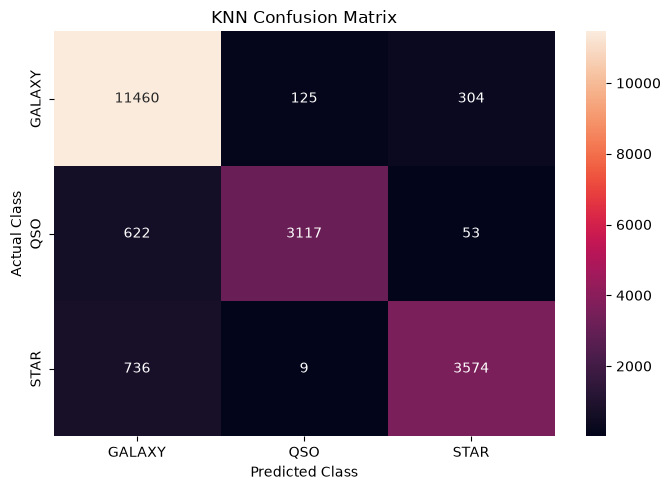

In [ ]:
# importing metrics 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)


# create the KNN model instance 
knn = KNeighborsClassifier()
# possible values for the model's hyperparameters that we need to test
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "metric": ["euclidean", "manhattan"]
}
# Hyperparameter Tuning 
knn_grid = GridSearchCV(
    estimator=knn, 
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
# Testing 14 combinations ( k + distance metric )
knn_grid.fit(X_train_scaled, y_train)

#Best parameters 
print("Best Parameters:")
print(knn_grid.best_params_)
print("\nBest Cross-Validation F1 Score:")
print(round(knn_grid.best_score_, 4))

# GridSearchCV has already fitted the best estimator on the training data. You're selecting that fitted model here
best_knn = knn_grid.best_estimator_

# Model saving 
joblib.dump(best_knn, "models/knn_model.pkl")

# Prediction with the best selected model 
y_pred_knn = best_knn.predict(X_test_scaled)

# KNN EVALUATION 

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(
    y_test,
    y_pred_knn,
    average="weighted"
)
knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average="weighted"
)
knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)
# ROC-AUC using One-vs-Rest
y_prob_knn = best_knn.predict_proba(X_test_scaled)
knn_roc_auc = roc_auc_score(
    y_test,
    y_prob_knn,
    multi_class="ovr",
    average="weighted"
)
print("\nKNN Performance")
print("--------------------------------------")
print("Accuracy        :", round(knn_accuracy, 4))
print("Weighted Precision:", round(knn_precision, 4))
print("Weighted Recall   :", round(knn_recall, 4))
print("Weighted F1       :", round(knn_f1, 4))
print("ROC-AUC (OvR)     :", round(knn_roc_auc, 4))

# confusion matrix heat map
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show() 

# Storing evaluation results for model comparisions 
knn_results = {
    "Model": "KNN",
    "Accuracy": knn_accuracy,
    "Weighted Precision": knn_precision,
    "Weighted Recall": knn_recall,
    "Weighted F1": knn_f1,
    "ROC-AUC (OvR)": knn_roc_auc
}


Best Parameters:
{'max_depth': 10}

Best Cross-Validation F1 Score:
0.9678

Decision Tree Performance
--------------------------------------
Accuracy        : 0.9764
Macro Precision : 0.9765
Macro Recall    : 0.9685
Macro F1        : 0.9724

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.97      0.99      0.98     11889
         QSO       0.96      0.92      0.94      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



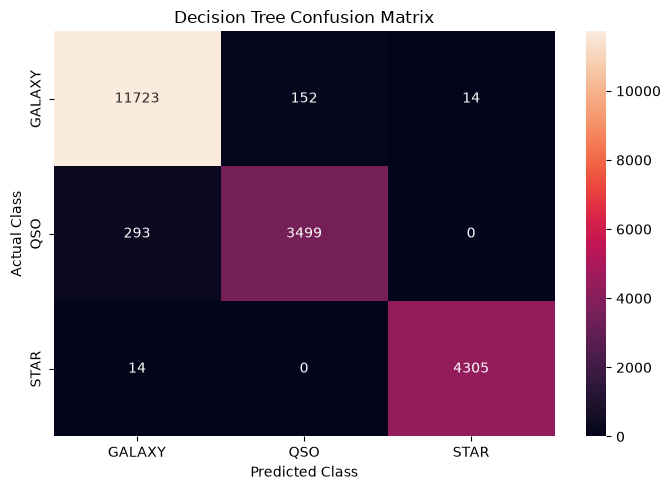

In [85]:
#--------------------------------------PART C (TRAINING )---------------------------------------------------------
# DECISION TREE 


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Hyperparameter tuning

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, 15, 20, None]
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

# Decision Tree does NOT require scaled data
dt_grid.fit(X_train, y_train)

print("Best Parameters:")
print(dt_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(dt_grid.best_score_, 4))


# Best Decision Tree

best_dt = dt_grid.best_estimator_

y_pred_dt = best_dt.predict(X_test)


# -------------------------------------- DECISION TREE EVALUATION --------------------------------------

dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="macro"
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="macro"
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="macro"
)

print("\nDecision Tree Performance")
print("--------------------------------------")
print("Accuracy        :", round(dt_accuracy, 4))
print("Macro Precision :", round(dt_precision, 4))
print("Macro Recall    :", round(dt_recall, 4))
print("Macro F1        :", round(dt_f1, 4))


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=label_encoder.classes_
    )
)


# -------------------------------------- CONFUSION MATRIX --------------------------------------

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Decision Tree Confusion Matrix")

plt.tight_layout()
plt.show()

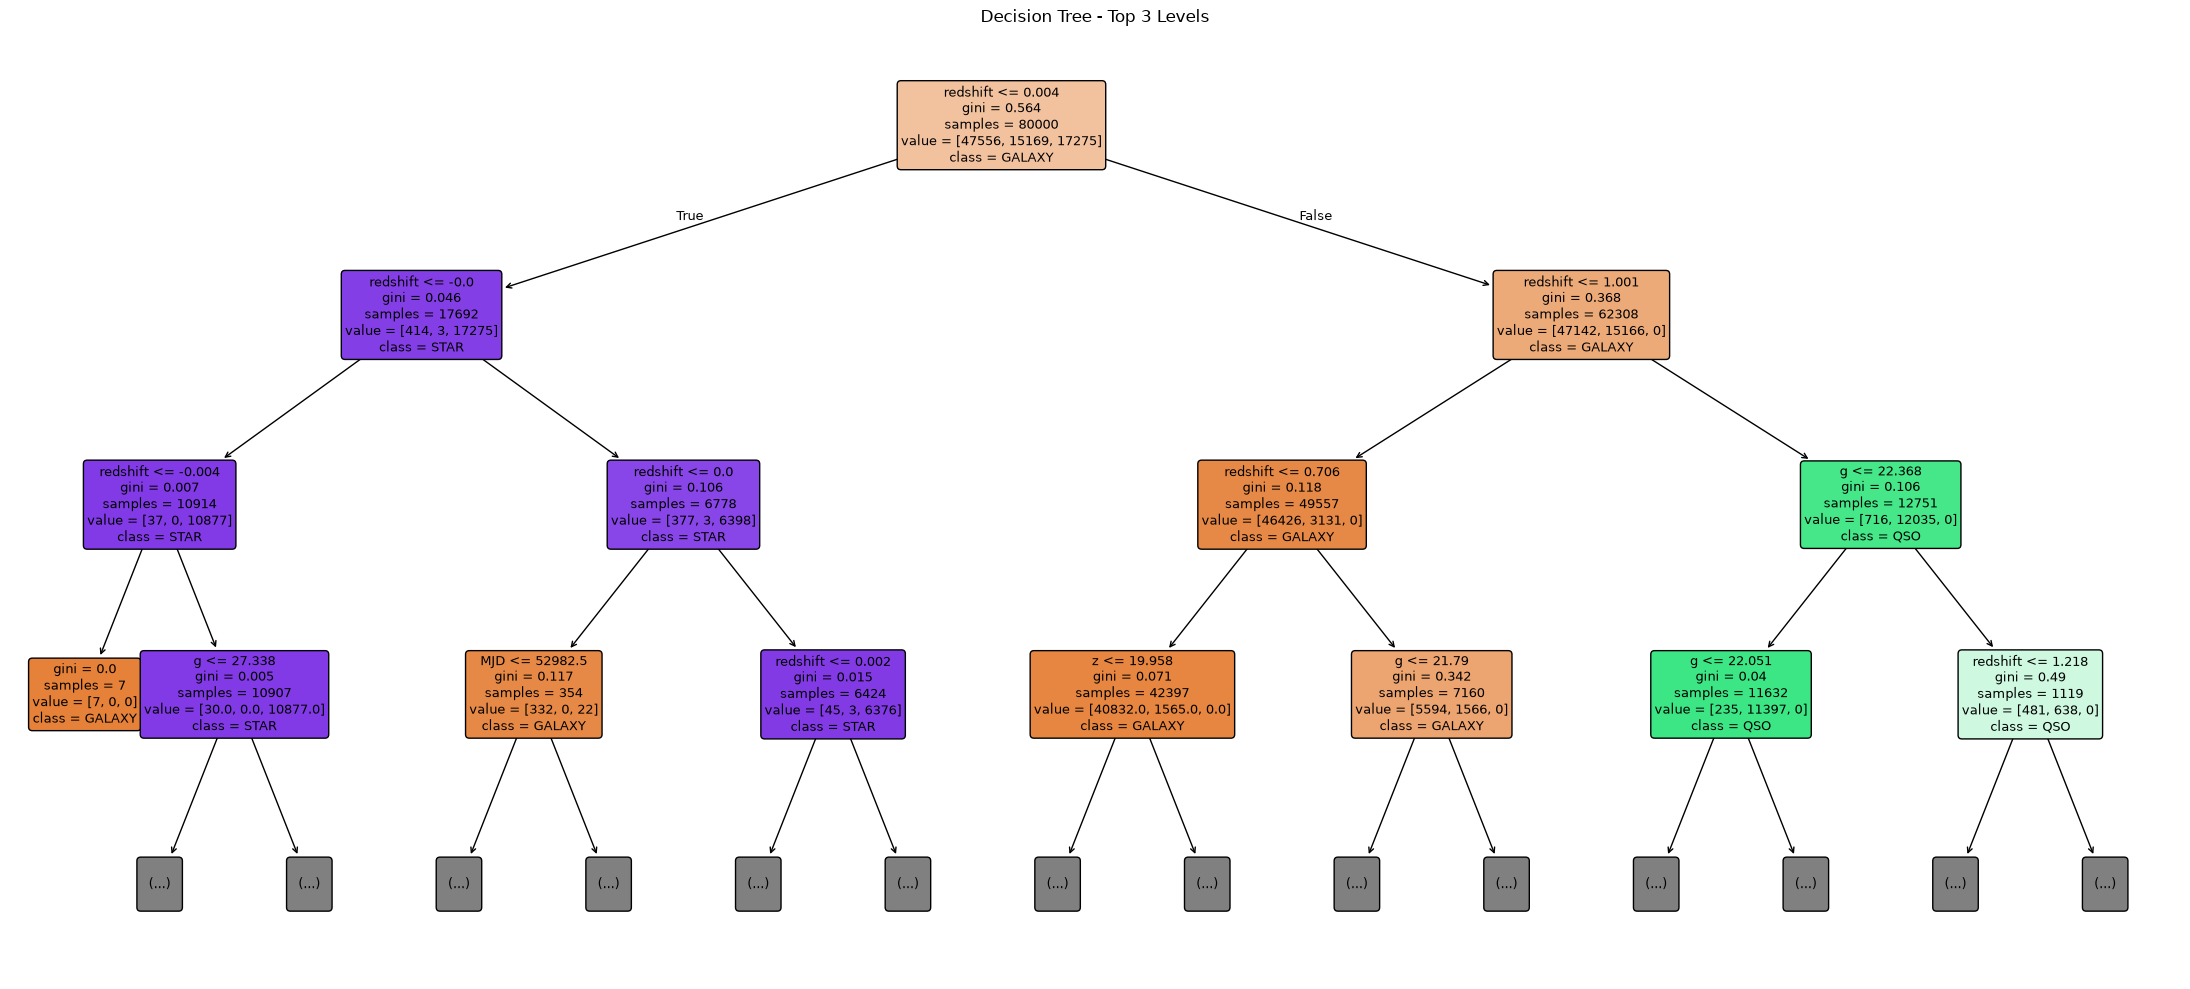

In [ ]:
# Create Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter tuning
param_grid_dt = {
    "max_depth": [3, 5, 7, 10, 15, 20, None]
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

# Train and tune Decision Tree
dt_grid.fit(X_train_scaled, y_train)

# Best parameters
print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)
print("\nBest Cross-Validation F1 Score:")
print(round(dt_grid.best_score_, 4))

# Select best model
best_dt = dt_grid.best_estimator_

# Save model
joblib.dump(best_dt, "models/decision_tree_model.pkl")

# Predictions
y_pred_dt = best_dt.predict(X_test_scaled)


# Evaluation

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="weighted"
)
dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="weighted"
)
dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted"
)
# ROC-AUC using One-vs-Rest
y_prob_dt = best_dt.predict_proba(X_test_scaled)
dt_roc_auc = roc_auc_score(
    y_test,
    y_prob_dt,
    multi_class="ovr",
    average="weighted"
)

print("\nDecision Tree Performance")
print("--------------------------------------")
print("Accuracy           :", round(dt_accuracy, 4))
print("Weighted Precision :", round(dt_precision, 4))
print("Weighted Recall    :", round(dt_recall, 4))
print("Weighted F1        :", round(dt_f1, 4))
print("ROC-AUC (OvR)      :", round(dt_roc_auc, 4))


# Confusion matrix Heat Map 

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()


# DECISION TREE VISUALIZATION 

plt.figure(figsize=(20, 10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.show()


# Results stored for model comparision 
dt_results = {
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Weighted Precision": dt_precision,
    "Weighted Recall": dt_recall,
    "Weighted F1": dt_f1,
    "ROC-AUC (OvR)": dt_roc_auc
}

### C5. Support Vector Machine (SVM)

Support Vector Machine is used for multiclass classification. The features are standardized before training because SVM is sensitive to feature scale. The hyperparameters C and kernel are tuned using cross-validation to identify a suitable model configuration.

In [ ]:
# Create SVM model
svm = SVC(
    probability=True,
    random_state=42
)

# Hyperparameter tuning
param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"]
}

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

# Train and tune SVM
svm_grid.fit(X_train_scaled, y_train)

# Best parameters
print("Best SVM Parameters:")
print(svm_grid.best_params_)
print("\nBest Cross-Validation F1 Score:")
print(round(svm_grid.best_score_, 4))

# Select best model
best_svm = svm_grid.best_estimator_

# Save model
joblib.dump(best_svm, "models/svm_model.pkl")

# Predictions
y_pred_svm = best_svm.predict(X_test_scaled)


# -------------------------------------- SVM EVALUATION --------------------------------------

svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    average="weighted"
)
svm_recall = recall_score(
    y_test,
    y_pred_svm,
    average="weighted"
)
svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="weighted"
)
# ROC-AUC using One-vs-Rest
y_prob_svm = best_svm.predict_proba(X_test_scaled)
svm_roc_auc = roc_auc_score(
    y_test,
    y_prob_svm,
    multi_class="ovr",
    average="weighted"
)

print("\nSVM Performance")
print("--------------------------------------")
print("Accuracy           :", round(svm_accuracy, 4))
print("Weighted Precision :", round(svm_precision, 4))
print("Weighted Recall    :", round(svm_recall, 4))
print("Weighted F1        :", round(svm_f1, 4))
print("ROC-AUC (OvR)      :", round(svm_roc_auc, 4))


# Confusion Matrix Heat Map 

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()


# Results stored for model comparsions 

svm_results = {
    "Model": "SVM",
    "Accuracy": svm_accuracy,
    "Weighted Precision": svm_precision,
    "Weighted Recall": svm_recall,
    "Weighted F1": svm_f1,
    "ROC-AUC (OvR)": svm_roc_auc
}

### 7. Model Evaluation and Comparison

All five classification models were evaluated using the same 80:20 stratified train-test split to ensure a fair comparison. The evaluation metrics include Accuracy, Weighted Precision, Weighted Recall, Weighted F1-score, and ROC-AUC using the One-vs-Rest (OvR) strategy.

Cross-validation was applied during hyperparameter tuning for KNN, Decision Tree, and SVM. The results of all models are presented together in the following summary table.

In [ ]:
# -------------------------------------- FINAL MODEL COMPARISON --------------------------------------

results = [
    knn_results,
    lr_results,
    gnb_results,
    dt_results,
    svm_results
]

comparison_df = pd.DataFrame(results)

# Round metric values
comparison_df = comparison_df.round(4)
print("Final Model Comparison")
display(comparison_df)
